**Importing libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

**Loading the required files from our previous operations on the same dataset**

In [ ]:
rf = joblib.load('Churn-Classification.joblib')
calibrated_rf = joblib.load("calibrated_rf.pkl")
encoder = joblib.load("ohe_encoder.pkl")
num_cols = joblib.load("num_cols.pkl")
cat_cols = joblib.load("cat_cols.pkl")

**Pre-Processing Pipeline** <br>


We initialise the same pipeline we used earlier to train our model

In [ ]:
raw_data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
raw_data = raw_data.drop('customerID', axis=1)
raw_data['TotalCharges'] = pd.to_numeric(raw_data['TotalCharges'], errors='coerce')
raw_data.dropna(inplace=True)

X = raw_data.drop(columns=["Churn"])
Y = raw_data["Churn"].map({"Yes": 1, "No": 0})

# Encoding in the same way
X_cat = encoder.transform(X[cat_cols])
X_final = np.hstack([X[num_cols].values, X_cat])

Making sure there's no ambiguity

In [ ]:
print(X_final.shape)

(7032, 30)


**Getting started with core technacilities**

First we predict the churn probabilities of different customers

In [ ]:
raw_data["churn_proba"] = rf.predict_proba(X_final)[:, 1]

print("Mean predicted churn probability:", raw_data["churn_proba"].mean())
print("Actual churn rate:", Y.mean())

Mean predicted churn probability: 0.41723040905594877
Actual churn rate: 0.26578498293515357


Overviewing the probabilities

In [ ]:
raw_data["churn_proba"].describe()

,churn_proba
count,7032.000000
mean,0.417230
std,0.266262
min,0.019865
25%,0.169419
50%,0.410429
75%,0.656195
max,0.918155


Using the caliberated model so as to keep the probabilities aligned with real world scale as the probabilities are going to be the one of the centerpiece metrcic for our evaluation

In [ ]:
raw_data["churn_proba"] = calibrated_rf.predict_proba(X_final)[:, 1]

In [ ]:
print("Mean predicted:", raw_data["churn_proba"].mean())
print("Actual churn rate:", Y.mean())

Mean predicted: 0.26276490202656827
Actual churn rate: 0.26578498293515357


Now we see a much better alignment with real world probabilities, let's visualise it

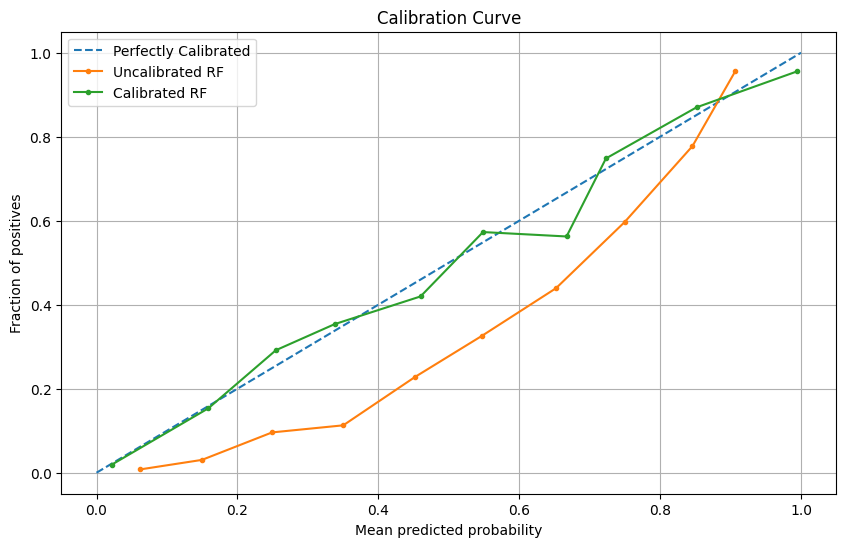

In [ ]:
from sklearn.calibration import calibration_curve

prob_uncalibrated = rf.predict_proba(X_final)[:, 1]
prob_calibrated = calibrated_rf.predict_proba(X_final)[:, 1]

fop_uncalibrated, mpv_uncalibrated = calibration_curve(Y, prob_uncalibrated, n_bins=10)
fop_calibrated, mpv_calibrated = calibration_curve(Y, prob_calibrated, n_bins=10)

plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.plot(mpv_uncalibrated, fop_uncalibrated, marker='.', label='Uncalibrated RF')
plt.plot(mpv_calibrated, fop_calibrated, marker='.', label='Calibrated RF')

plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()

**Business Side**
<br> Now we calculate various business metrics so we can proceed with better evaluation of the task at hand, which is to maximise the profit.

We calculate CLV as a product of Monthly Charges and Number of Months a year as we do not know how long the customer might stay.

In [ ]:
raw_data["CLV"] = raw_data["MonthlyCharges"] * 12
raw_data["CLV"].describe()

,CLV
count,7032.000000
mean,777.578498
std,361.031687
min,219.000000
25%,427.050000
50%,844.200000
75%,1078.350000
max,1425.000000


Assuming the retention cost and success rate as constant values

In [ ]:
retention_cost = 200
success_rate = 0.30

Extracting the expected value

In [ ]:
raw_data["expected_value"] = (
    raw_data["churn_proba"] * raw_data["CLV"] * success_rate
) - retention_cost

raw_data["expected_value"].describe()

,expected_value
count,7032.000000
mean,-129.461451
std,75.528058
min,-200.000000
25%,-191.505946
50%,-156.228921
75%,-86.530893
max,165.220000


How many customers are actually profitable?

In [ ]:
(raw_data["expected_value"] > 0).sum()

np.int64(541)

Estimating expected total profit taking in consideration the budget

In [ ]:
target_candidates = raw_data.sort_values(
    by="expected_value",
    ascending=False
)

budget = 50000
max_customers = budget // retention_cost

target_customers = target_candidates.head(int(max_customers))

expected_profit = target_customers["expected_value"].sum()
print(expected_profit)

18821.688016606895


How many customers can we target?

In [ ]:
max_customers

250

Plotting the retention vs profit curve so as to understand the point where profit starts to saturate

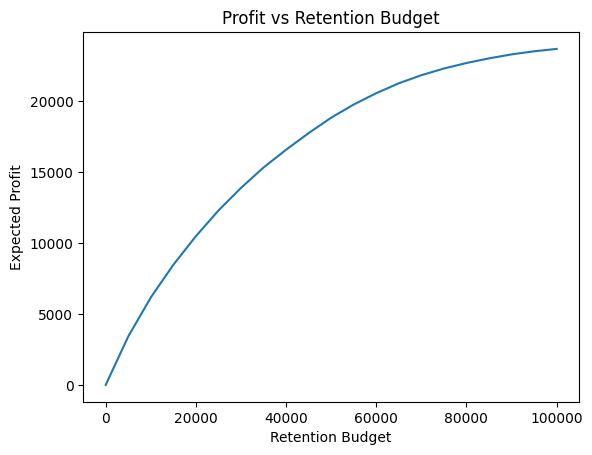

In [ ]:
sorted_customers = raw_data.sort_values(
    by="expected_value",
    ascending=False
)

budgets = range(0, 100001, 5000)
profits = []

for b in budgets:
    max_customers = b // retention_cost
    targeted = sorted_customers.head(int(max_customers))
    profit = targeted["expected_value"].sum()
    profits.append(profit)

import matplotlib.pyplot as plt

plt.plot(budgets, profits)
plt.xlabel("Retention Budget")
plt.ylabel("Expected Profit")
plt.title("Profit vs Retention Budget")
plt.show()

Now that we have a budget based model we try to frame another model based on the churn probability itself.

In [ ]:
thresholds = np.linspace(0,1,100)
profits = []
customers_targeted = []

for t in thresholds:

    targeted = raw_data[raw_data["churn_proba"] >= t]

    profit = targeted["expected_value"].sum()

    profits.append(profit)
    customers_targeted.append(len(targeted))

It's a very simpler stratergy to implement and less precise

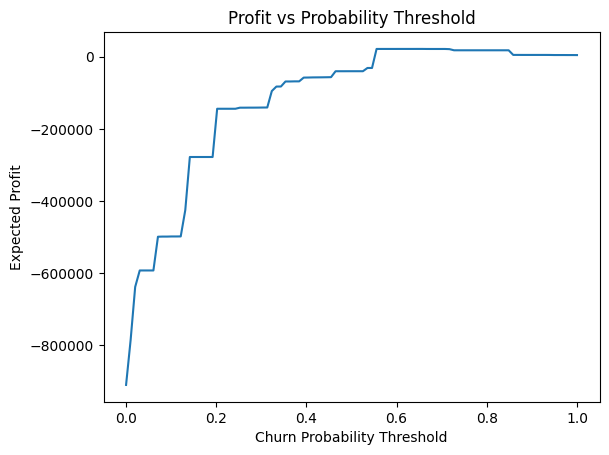

In [ ]:
plt.plot(thresholds, profits)
plt.xlabel("Churn Probability Threshold")
plt.ylabel("Expected Profit")
plt.title("Profit vs Probability Threshold")
plt.show()

We pick out the best possible metrics from the bunch

In [ ]:
best_idx = np.argmax(profits)

best_threshold = thresholds[best_idx]
best_profit = profits[best_idx]
customers = customers_targeted[best_idx]

print("Best Threshold:", best_threshold)
print("Expected Profit:", best_profit)
print("Customers Targeted:", customers)

Best Threshold: 0.6464646464646465
Expected Profit: 21796.18691687479
Customers Targeted: 596


Finally understanding the difference between Top Targets and Normal Customers

In [ ]:
top_targets = raw_data.sort_values("expected_value", ascending=False).head(100)
top_targets[["tenure","MonthlyCharges","Contract"]].describe()

,tenure,MonthlyCharges
count,100.00000,100.000000
mean,3.43000,93.644500
std,2.86834,5.938617
min,1.00000,77.150000
25%,1.00000,90.587500
50%,2.00000,94.150000
75%,5.00000,96.337500
max,11.00000,105.900000


In [ ]:
raw_data[["tenure","MonthlyCharges","Contract"]].describe()

,tenure,MonthlyCharges
count,7032.000000,7032.000000
mean,32.421786,64.798208
std,24.545260,30.085974
min,1.000000,18.250000
25%,9.000000,35.587500
50%,29.000000,70.350000
75%,55.000000,89.862500
max,72.000000,118.750000




#**Summary**

This project extends beyond traditional churn prediction and focuses on building a **profit-oriented customer retention decision system**. Instead of only identifying which customers are likely to churn, the objective was to determine **which customers should actually be targeted with retention interventions** in order to maximize business value.

The project began by training a Random Forest model to estimate the probability of customer churn. Since the downstream decision process relies directly on the accuracy of these probabilities, the model outputs were calibrated using probability calibration techniques. Calibration ensures that predicted probabilities align closely with the observed churn rates, making them reliable inputs for financial decision modeling.

Once calibrated probabilities were obtained, the analysis shifted from pure prediction toward **economic optimization**. A proxy for Customer Lifetime Value (CLV) was estimated using each customer's monthly charges multiplied by an assumed future retention horizon. Two business assumptions were introduced to simulate a realistic retention campaign: the cost of offering a retention incentive and the expected success rate of that intervention.

Using these inputs, an **expected value calculation** was performed for each customer. This calculation estimates the financial impact of targeting a particular customer with a retention offer. Customers with negative expected value represent economically inefficient interventions, while customers with positive expected value represent profitable retention opportunities.

To simulate real-world operational constraints, a **budget-based targeting strategy** was implemented. Customers were ranked by expected value, and the top candidates were selected under a fixed campaign budget. Under a retention budget of \$50,000 and an assumed offer cost of \$200 per customer, the system recommended targeting 250 customers, producing an estimated profit of approximately \$18,800.

In addition to budget-constrained optimization, a **probability threshold policy** was also analyzed. By evaluating profit across different churn probability thresholds, an optimal targeting threshold of approximately **0.646** was identified. Applying this rule would target roughly 596 customers and generate an estimated profit of approximately **\$21,800** under the assumed campaign parameters.

The analysis revealed an important operational insight: only a small fraction of customers are economically worth targeting. In this dataset, roughly **8% of customers produced positive expected value**, indicating that indiscriminate retention campaigns would likely result in significant financial losses. The model therefore provides a disciplined strategy that focuses retention resources on customers where intervention produces measurable business return.

Overall, this project demonstrates how machine learning can move beyond prediction and support decision-focused analytics. By combining churn prediction, probability calibration, customer value estimation, and cost-sensitive optimization, the resulting system provides actionable guidance on how retention budgets should be allocated to maximize profitability.
